In [1]:
# Ignore warnings to keep outputs clean
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# FINAL PROJECT: Churn Prediction & Data Drift (FULL VERSION - STABLE)
# ==========================================================

import os
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [2]:
# ==========================================================
# 1. LOAD DATA
# ==========================================================

FILE_NAME = "data_tp_churn.csv"
df = pd.read_csv(FILE_NAME)

df.rename(columns={
    'Periode': 'Period',
    'Anciennete': 'Tenure',
    'Montant_Mensuel': 'Monthly_Amount',
    'Support_Appels': 'Support_Calls',
    'Contrat': 'Contract'
}, inplace=True)

df = df.sort_values("Period").reset_index(drop=True)
print("Periods:", df["Period"].unique())
df.head()


Periods: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


,Period,Tenure,Monthly_Amount,Support_Calls,Contract,Churn
0,1,18,54.46,0.0,Mensuel,0
1,1,1,58.66,0.0,Mensuel,1
2,1,25,111.01,1.0,1 an,0
3,1,40,34.67,2.0,1 an,0
4,1,37,81.08,2.0,1 an,0


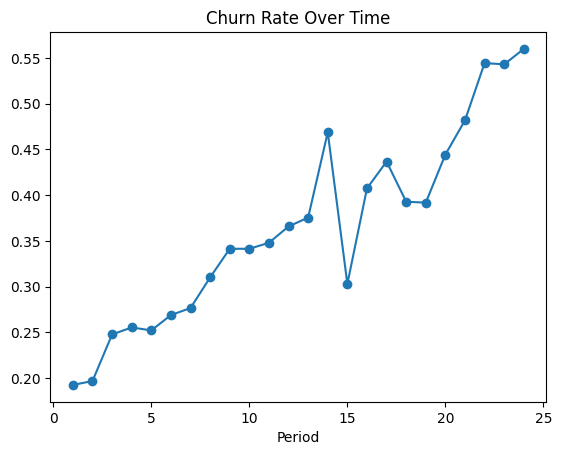

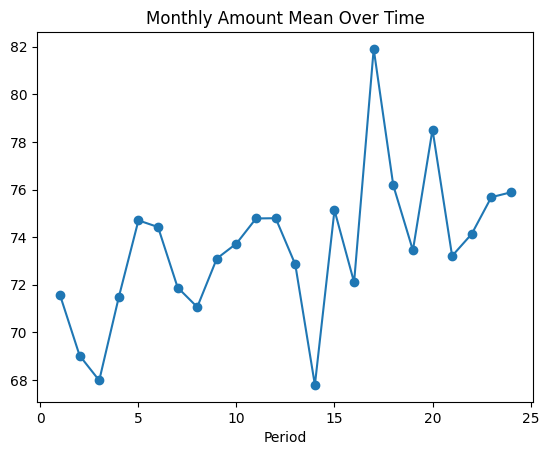

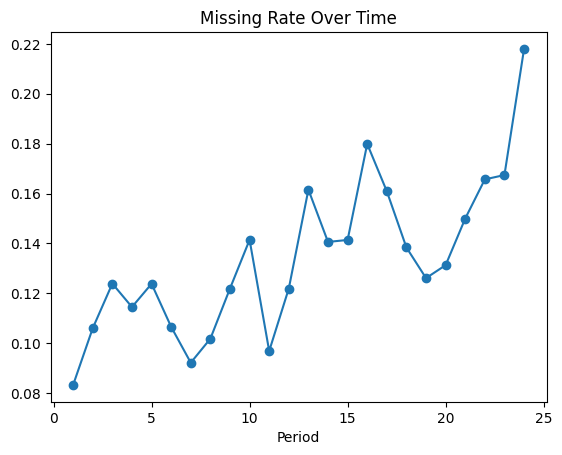

In [3]:
# ==========================================================
# 2. DRIFT EDA
# ==========================================================

df.groupby("Period")["Churn"].mean().plot(marker='o')
plt.title("Churn Rate Over Time")
plt.show()

df.groupby("Period")["Monthly_Amount"].mean().plot(marker='o')
plt.title("Monthly Amount Mean Over Time")
plt.show()

df.groupby("Period")["Monthly_Amount"].apply(lambda x: x.isnull().mean()).plot(marker='o')
plt.title("Missing Rate Over Time")
plt.show()


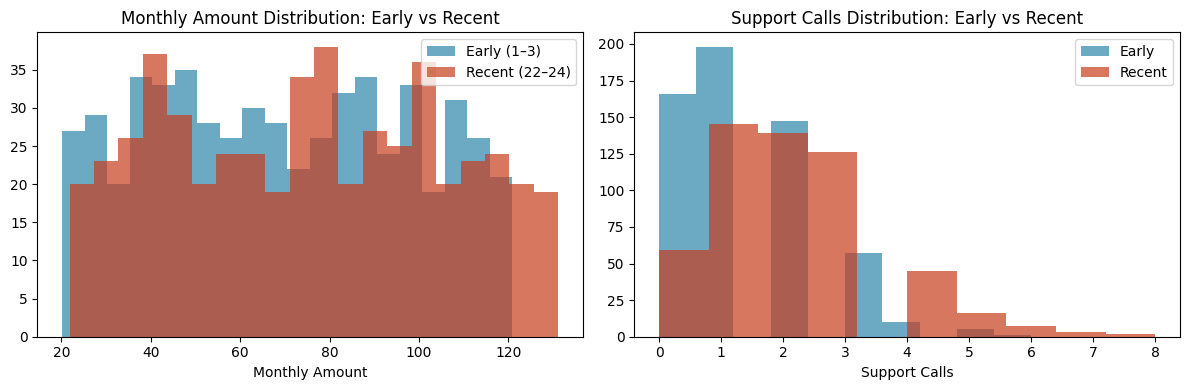

In [10]:
# Distribution comparison: Early vs Recent periods
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

early_periods = sorted(df["Period"].unique())[:3]
recent_periods = sorted(df["Period"].unique())[-3:]

early = df[df["Period"].isin(early_periods)]["Monthly_Amount"].dropna()
recent = df[df["Period"].isin(recent_periods)]["Monthly_Amount"].dropna()

axes[0].hist(early, bins=20, alpha=0.7, color='#2E86AB', label=f"Early ({early_periods[0]}–{early_periods[-1]})")
axes[0].hist(recent, bins=20, alpha=0.7, color='#C73E1D', label=f"Recent ({recent_periods[0]}–{recent_periods[-1]})")
axes[0].set_title("Monthly Amount Distribution: Early vs Recent")
axes[0].set_xlabel("Monthly Amount")
axes[0].legend()

support_early = df[df["Period"].isin(early_periods)]["Support_Calls"]
support_recent = df[df["Period"].isin(recent_periods)]["Support_Calls"]

axes[1].hist(support_early, bins=10, alpha=0.7, color='#2E86AB', label=f"Early")
axes[1].hist(support_recent, bins=10, alpha=0.7, color='#C73E1D', label=f"Recent")
axes[1].set_title("Support Calls Distribution: Early vs Recent")
axes[1].set_xlabel("Support Calls")
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# ==========================================================
# 3. PIPELINE
# ==========================================================

numeric_cols = ["Tenure", "Monthly_Amount", "Support_Calls"]
categorical_cols = ["Contract"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_cols),
    ("cat", cat_pipeline, categorical_cols)
])


In [5]:
# ==========================================================
# 4. ROLLING EVALUATION FUNCTION
# ==========================================================

def rolling_evaluation(model_type="logistic", window=None):

    periods = sorted(df["Period"].unique())
    aucs = []
    test_periods = []

    for i in range(3, len(periods)):

        if window is None:
            train_periods = periods[:i]
        else:
            train_periods = periods[max(0, i-window):i]

        test_period = periods[i]

        train_df = df[df["Period"].isin(train_periods)]
        test_df = df[df["Period"] == test_period]

        X_train = train_df.drop("Churn", axis=1)
        y_train = train_df["Churn"]
        X_test = test_df.drop("Churn", axis=1)
        y_test = test_df["Churn"]

        if model_type == "logistic":
            clf = LogisticRegression(
                max_iter=2000,
                solver="lbfgs",
                C=0.5,
                class_weight="balanced"
            )
        else:
            clf = RandomForestClassifier(n_estimators=100, random_state=42)

        model = Pipeline([
            ("prep", preprocessor),
            ("clf", clf)
        ])

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]

        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, probs)
        else:
            auc = np.nan

        aucs.append(auc)
        test_periods.append(test_period)

    return test_periods, aucs


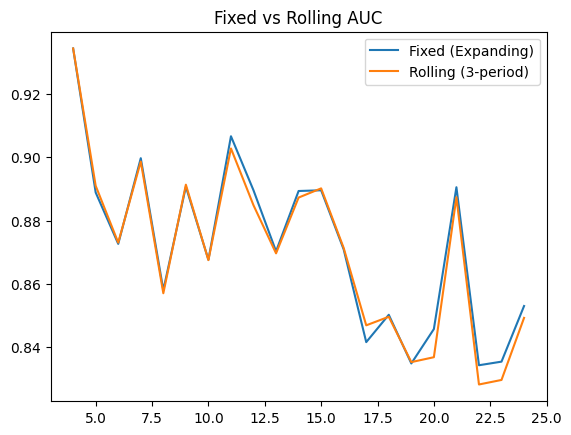

In [6]:
# ==========================================================
# 5. FIXED vs ROLLING
# ==========================================================

periods_fixed, auc_fixed = rolling_evaluation("logistic", window=None)
periods_roll, auc_roll = rolling_evaluation("logistic", window=3)

plt.plot(periods_fixed, auc_fixed, label="Fixed (Expanding)")
plt.plot(periods_roll, auc_roll, label="Rolling (3-period)")
plt.legend()
plt.title("Fixed vs Rolling AUC")
plt.show()


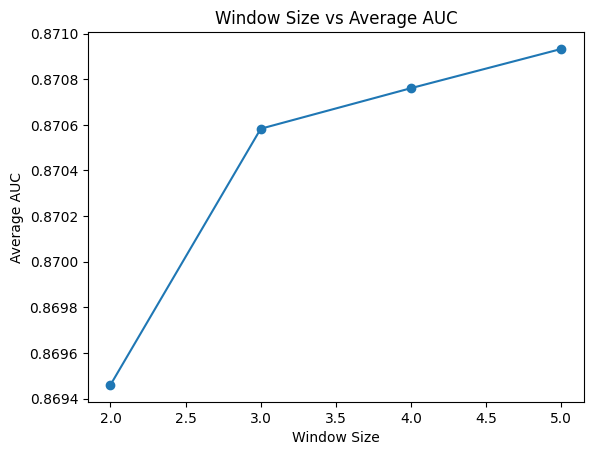

Best Window Size: 5


In [7]:
# ==========================================================
# 6. AUTOMATIC WINDOW SELECTION
# ==========================================================

window_candidates = [2, 3, 4, 5]
window_scores = []

for w in window_candidates:
    _, aucs = rolling_evaluation("logistic", window=w)
    window_scores.append(np.nanmean(aucs))

plt.plot(window_candidates, window_scores, marker='o')
plt.title("Window Size vs Average AUC")
plt.xlabel("Window Size")
plt.ylabel("Average AUC")
plt.show()

best_window = window_candidates[np.argmax(window_scores)]
print("Best Window Size:", best_window)


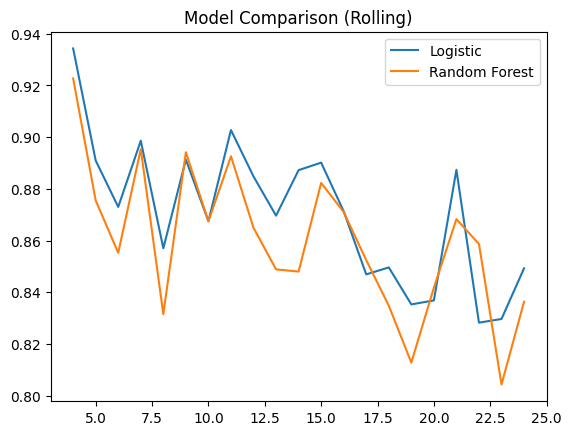

In [8]:
# ==========================================================
# 7. RANDOM FOREST COMPARISON
# ==========================================================

_, auc_rf = rolling_evaluation("rf", window=best_window)

plt.plot(periods_roll, auc_roll, label="Logistic")
plt.plot(periods_roll, auc_rf, label="Random Forest")
plt.legend()
plt.title("Model Comparison (Rolling)")
plt.show()


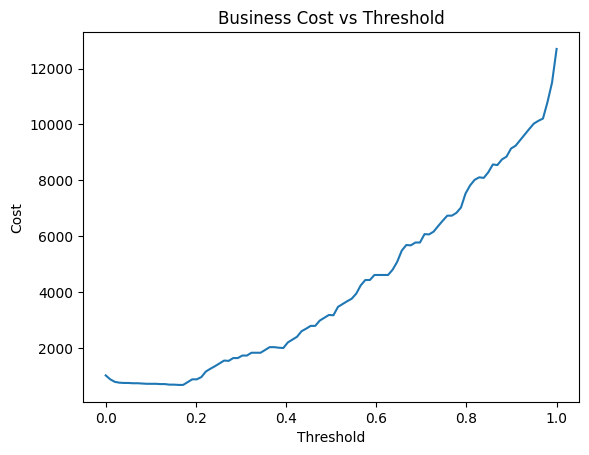

Optimal Threshold: 0.16161616161616163


In [9]:
# ==========================================================
# 8. BUSINESS COST CURVE
# ==========================================================

periods = sorted(df["Period"].unique())
train_periods = periods[-best_window-1:-1]
test_period = periods[-1]

train_df = df[df["Period"].isin(train_periods)]
test_df = df[df["Period"] == test_period]

X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]
X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

final_model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

final_model.fit(X_train, y_train)
probs = final_model.predict_proba(X_test)[:, 1]

COST_FP = 10
COST_FN = 100

thresholds = np.linspace(0,1,100)
costs = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    fp = np.sum((preds==1)&(y_test==0))
    fn = np.sum((preds==0)&(y_test==1))
    cost = fp*COST_FP + fn*COST_FN
    costs.append(cost)

plt.plot(thresholds, costs)
plt.title("Business Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Cost")
plt.show()

best_t = thresholds[np.argmin(costs)]
print("Optimal Threshold:", best_t)
